In [1]:
import xarray
import numpy as np

In [2]:
ds = xarray.open_dataset("../data/geo/terraclimate_output.nc", engine="netcdf4")

In [3]:
list(ds.data_vars)

['aet',
 'def',
 'pdsi',
 'pet',
 'ppt',
 'q',
 'soil',
 'srad',
 'swe',
 'tmax',
 'tmin',
 'vap',
 'vpd',
 'ws']

(array([   95.,  1042.,  3082., 10330.,  7793.,  7905., 12972.,  1200.,
          977.,   745.]),
 array([-6.69999981, -6.06999969, -5.43999958, -4.80999994, -4.17999983,
        -3.54999971, -2.91999984, -2.28999996, -1.65999985, -1.02999973,
        -0.39999998]),
 <BarContainer object of 10 artists>)

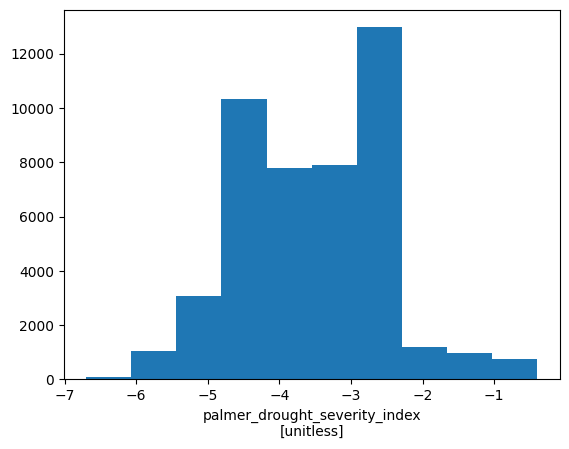

In [4]:
# ds.aet.median(dim="time").hist()
xarray.plot.hist(ds["pdsi"].median(dim="time"))

In [6]:
ds.median(dim="time")

<xarray.Dataset> Size: 4MB
Dimensions:  (lat: 212, lon: 277)
Coordinates:
  * lat      (lat) float64 2kB -30.94 -30.98 -31.02 ... -39.65 -39.69 -39.73
  * lon      (lon) float64 2kB 140.0 140.0 140.1 140.1 ... 151.4 151.4 151.5
Data variables: (12/14)
    aet      (lat, lon) float32 235kB 5.8 5.8 5.3 4.8 4.9 ... nan nan nan nan
    def      (lat, lon) float32 235kB 195.7 193.8 194.0 194.5 ... nan nan nan
    pdsi     (lat, lon) float32 235kB -0.9 -0.9 -0.8 -0.8 ... nan nan nan nan
    pet      (lat, lon) float32 235kB 199.2 197.1 197.1 197.4 ... nan nan nan
    ppt      (lat, lon) float64 470kB 6.1 6.1 5.6 5.1 5.2 ... nan nan nan nan
    q        (lat, lon) float64 470kB 0.3 0.3 0.3 0.3 0.3 ... nan nan nan nan
    ...       ...
    swe      (lat, lon) float64 470kB 0.0 0.0 0.0 0.0 0.0 ... nan nan nan nan
    tmax     (lat, lon) float32 235kB 30.7 30.8 30.8 30.7 ... nan nan nan nan
    tmin     (lat, lon) float32 235kB 14.4 14.6 14.5 14.5 ... nan nan nan nan
    vap      (lat, lon) float32 235kB 0.802 0.795 0.788 0.789 ... nan nan nan
    vpd      (lat, lon) float32 235kB 2.34 2.35 2.35 2.35 ... nan nan nan nan
    ws       (lat, lon) float32 235kB 3.6 3.6 3.6 3.6 3.5 ... nan nan nan nan
Attributes: (12/52)
    Conventions:                     CF-1.6
    acknowledgment:                  Please cite the references included here...
    cdm_data_type:                   GRID
    contributor_email:               khegewisch@ucmerced.edu
    contributor_name:                Katherine Hegewisch
    contributor_role:                Postdoctoral Fellow
    ...                              ...
    time_coverage_duration:          P1Y
    time_coverage_end:               1958-12-01T00:0
    time_coverage_resolution:        P1M
    time_coverage_start:             1958-01-01T00:0
    title:                           TerraClimate: monthly climate and climat...
    version:                         v1.0

In [1]:
import sys
import os
import importlib


sys.path.append("../scripts")

from map_satellite_data import map_satellite_data # type: ignore

In [2]:
mapped_data = map_satellite_data(ds_path="../data/geo/terraclimate_output.nc", csv_path="../data/Training_Data.csv")

Extracting raster values: 100%|██████████| 6312/6312 [00:43<00:00, 144.56it/s]


In [3]:
mapped_data

,latitude,longitude,aet,def,pdsi,pet,ppt,q,soil,srad,swe,tmax,tmin,vap,vpd,ws
0,-34.027900,150.771000,53.500000,65.300003,-4.5,115.500000,49.7,2.5,16.700001,200.799149,0.0,23.9,12.599999,1.233,0.81,3.6
1,-34.821595,147.193697,24.700001,110.900002,-3.9,144.699997,25.9,1.3,2.500000,218.403992,0.0,24.5,10.900000,0.942,1.33,3.1
2,-36.617759,146.882941,51.299999,28.200001,-3.8,115.099998,69.9,3.5,68.800003,204.000031,0.0,21.4,8.099999,0.942,0.78,3.2
3,-37.470900,144.744000,40.299999,67.700005,-4.7,119.300003,45.2,2.3,12.400001,204.096054,0.0,20.1,8.000000,0.948,0.70,4.2
4,-38.400153,145.018560,58.900002,29.500000,-4.8,109.500000,71.1,3.6,43.000000,189.203964,0.0,18.9,9.900000,1.096,0.50,5.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6307,-33.877000,150.834000,51.400002,65.400002,-4.5,118.099998,50.9,2.5,15.200000,201.799423,0.0,24.1,13.099999,1.263,0.81,3.7
6308,-36.300563,140.975690,30.500000,90.800003,-2.6,127.800003,28.0,1.4,8.200000,212.802444,0.0,22.0,7.900000,0.998,0.92,3.8
6309,-37.882022,147.682533,36.799999,60.799999,-4.8,121.700005,38.0,1.9,5.900000,189.700104,0.0,21.5,9.900000,1.106,0.61,4.7
6310,-37.626000,143.763000,40.600002,47.100002,-3.8,111.200005,49.8,2.5,26.200001,200.999207,0.0,18.6,7.100000,0.941,0.58,4.4


In [4]:
mapped_data.dtypes

latitude     float64
longitude    float64
aet          float64
def          float64
pdsi         float64
pet          float64
ppt          float64
q            float64
soil         float64
srad         float64
swe          float64
tmax         float64
tmin         float64
vap          float64
vpd          float64
ws           float64
dtype: object

In [10]:
mapped_data.reset_index().describe()

,index,latitude,longitude
count,6312.000000,6312.000000,6312.000000
mean,3155.500000,-35.881502,146.794791
std,1822.261781,1.774886,2.744209
min,0.000000,-39.060582,140.244264
25%,1577.750000,-37.477086,144.676919
50%,3155.500000,-36.079450,146.749611
75%,4733.250000,-34.472848,149.258912
max,6311.000000,-30.947600,151.170776


In [16]:
import xarray as xr

ds = xr.open_dataset("../data/geo/terraclimate_output.nc")

In [19]:
ds.dims

FrozenMappingWarningOnValuesAccess({'time': 25, 'lat': 212, 'lon': 277})

In [27]:
ds.median(dim="time")["soil"].sel(lat=0, lon=0, method="nearest").values.item()

0.0